In [51]:
import torch
import pandas as pd
import numpy as np
import os
import cv2  # для загрузки изображений
import seaborn as sns
from tqdm import tqdm

In [52]:
# Путь к папке с изображениями и .txt файлами
data_folder = './dataset'

# Списки для хранения данных
X = []
Y = []

# Проходим по всем файлам в папке
for filename in tqdm(os.listdir(data_folder)):
    # Полный путь к изображению
    img_path = os.path.join(data_folder, filename)
    
    # Полный путь к соответствующему .txt файлу
    txt_filename = os.path.splitext(filename)[0] + '.txt'
    txt_path = os.path.join(data_folder, txt_filename)
    
    # Загрузка изображения
    img = cv2.imread(img_path, 0)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    X.append(img_rgb.reshape(3,256,256))
    Y.append(filename)


100%|██████████| 9605/9605 [01:08<00:00, 139.93it/s]


In [53]:
X = torch.Tensor(X)

In [54]:
X.shape

torch.Size([9605, 3, 256, 256])

In [55]:
device=torch.device("cuda:0")

In [56]:
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests
import os

processor = ViTImageProcessor.from_pretrained('facebook/dino-vitb16')
model = ViTModel.from_pretrained('facebook/dino-vitb16').to(device)

data_folder = './dataset'

# Списки для хранения данных
df = pd.DataFrame()

for filename in tqdm(os.listdir(data_folder)):
    img_path = os.path.join(data_folder, filename)
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()
    df = pd.concat((df, pd.DataFrame(cls_embedding)), axis=0)


Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 9605/9605 [08:19<00:00, 19.24it/s]


In [57]:
Y[3083]

'3083.png'

In [67]:
df = pd.concat((df.reset_index(drop=True), pd.DataFrame(Y, columns=["target"])),axis=1)

In [69]:
df.to_csv("dino-vitb16.csv", index=False)

In [70]:
df = pd.read_csv("dino-vitb16.csv")

In [71]:
import torch
import pandas as pd
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
emb_target = pd.read_csv("dino-vitb16.csv")

In [73]:
emb_target.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,target
0,-0.696392,0.506082,0.061274,2.548204,-1.514238,-0.323813,-2.044237,0.698627,-3.631322,2.337856,...,0.081015,0.155273,0.280295,-0.770449,-2.002456,1.151720,1.651979,-2.622741,-1.826417,0000.png
1,2.625819,-2.629881,-2.296542,-0.907852,-0.381279,-0.021805,-1.133389,-2.937737,-1.391853,-0.151969,...,3.761973,2.011420,-0.321893,-0.368574,0.895072,0.365689,0.817058,1.735861,-2.248994,0001.png
2,4.517957,0.902219,1.525593,-1.237498,1.461054,-3.943575,-2.174957,-0.720740,-2.296613,3.293845,...,-0.149273,2.380937,-0.532091,-0.723532,4.059513,3.210793,0.051437,1.859101,0.364564,0002.png
3,1.430973,0.082387,2.930414,-4.301381,3.247382,0.192765,-0.389212,1.465804,2.693513,2.903575,...,-0.562226,2.543649,0.924837,-1.140435,-0.014423,3.767035,-0.395648,-5.033008,0.287532,0003.png
4,-1.093481,-3.500600,1.769979,-1.977163,-0.400424,-0.274861,2.894737,-3.274831,-0.474486,4.133061,...,-0.230443,1.560291,-0.272577,-0.882835,-2.684399,1.656842,-1.600106,-0.567725,0.280449,0004.png


In [74]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [75]:
emb_target.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,target
0,-0.696392,0.506082,0.061274,2.548204,-1.514238,-0.323813,-2.044237,0.698627,-3.631322,2.337856,...,0.081015,0.155273,0.280295,-0.770449,-2.002456,1.151720,1.651979,-2.622741,-1.826417,0000.png
1,2.625819,-2.629881,-2.296542,-0.907852,-0.381279,-0.021805,-1.133389,-2.937737,-1.391853,-0.151969,...,3.761973,2.011420,-0.321893,-0.368574,0.895072,0.365689,0.817058,1.735861,-2.248994,0001.png
2,4.517957,0.902219,1.525593,-1.237498,1.461054,-3.943575,-2.174957,-0.720740,-2.296613,3.293845,...,-0.149273,2.380937,-0.532091,-0.723532,4.059513,3.210793,0.051437,1.859101,0.364564,0002.png
3,1.430973,0.082387,2.930414,-4.301381,3.247382,0.192765,-0.389212,1.465804,2.693513,2.903575,...,-0.562226,2.543649,0.924837,-1.140435,-0.014423,3.767035,-0.395648,-5.033008,0.287532,0003.png
4,-1.093481,-3.500600,1.769979,-1.977163,-0.400424,-0.274861,2.894737,-3.274831,-0.474486,4.133061,...,-0.230443,1.560291,-0.272577,-0.882835,-2.684399,1.656842,-1.600106,-0.567725,0.280449,0004.png


In [76]:
embedding_X = emb_target.drop(["target"], axis=1)
embedding_X.to_numpy().shape
embedding_X = np.asarray(embedding_X, dtype=np.float32)

In [77]:
import faiss
import numpy as np

embedding_X = np.ascontiguousarray(embedding_X)

faiss.normalize_L2(embedding_X)
# Создание индекса
index = faiss.IndexFlatIP(embedding_X.shape[1])

# Добавляем эмбеддинги в индекс
index.add(embedding_X)

print(f"Всего в индексе {index.ntotal} эмбеддингов")
res = pd.DataFrame()
# Теперь делаем запрос
for i in range(9605):
    query_embedding = embedding_X[i].reshape(1,embedding_X.shape[1])
    query_embedding = np.ascontiguousarray(query_embedding)
    faiss.normalize_L2(query_embedding)

    k = 7
    distances, indices = index.search(query_embedding, k)

    indices = pd.DataFrame(indices)
    res = pd.concat((res,indices), axis=0)

rank_columns = [1,2,3,4,5,6]
res['ranking'] = res[rank_columns].apply(
    lambda row: ' '.join([f"{x:04d}.png" for x in row]),
    axis=1
)
res = res.drop(rank_columns, axis=1)
res[0] = res[0].map(lambda x: f"{x:04d}.png")
res = res.rename(columns={0:"filename"})

Всего в индексе 9605 эмбеддингов


In [78]:
res.head()

,filename,ranking
0,0000.png,2023.png 7447.png 8492.png 5486.png 7420.png 8...
0,0001.png,3598.png 5193.png 1995.png 5029.png 5721.png 6...
0,0002.png,7688.png 1858.png 3977.png 2448.png 4568.png 8...
0,0003.png,1348.png 3737.png 9534.png 0800.png 8440.png 5...
0,0004.png,6371.png 4191.png 4593.png 7238.png 0258.png 2...


In [201]:
res.to_csv("res.csv", index=False, header=True)

In [236]:
print(indices)

      0     1     2     3     4     5     6
0  9604  7307  7174  7794  4951  4152  5514


In [237]:
emb_target["id"] = np.array([i for i in range(9605)]).reshape(9605,1)

In [238]:
emb_target = emb_target.set_index("id")

In [239]:
emb_target.loc[0, "target"]

'0000.png'

In [105]:
result = []
result.append(res.iloc[0]["filename"])
result.extend(res.iloc[0]["ranking"].split())

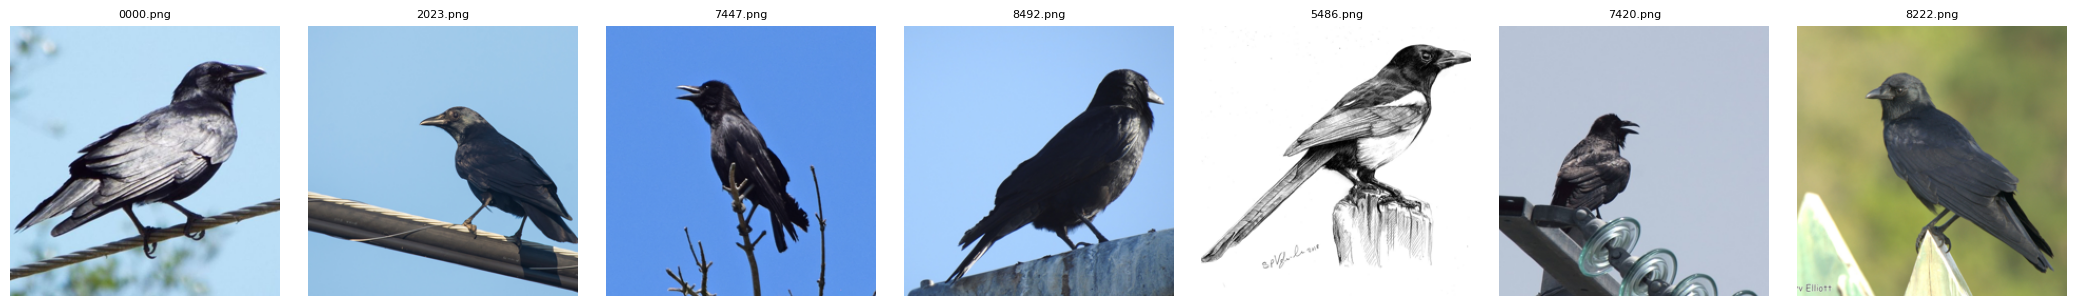

In [106]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 7, figsize=(21, 3))  # Ширина 21 дюйм для 7 изображений

# Убираем оси и отображаем изображения
for i, (ax, img_file) in enumerate(zip(axes, result)):
    img = mpimg.imread("./dataset/"+img_file)
    ax.imshow(img)
    ax.set_title(img_file, fontsize=8)  # Подпись с названием (уменьшенный шрифт)
    ax.axis('off')  # Скрываем оси

plt.tight_layout()  # Автоматическая настройка отступов
plt.show()

# Проверка

In [477]:
exp = pd.read_csv("res.csv")

In [478]:
sum = 0
for i in range(0,9605):
    if i!=int(exp.loc[i, "filename"][0:4]):
        print(i)
    for sim in exp.loc[i, "ranking"].split():
        if i == int(sim[0:4]) or int(sim[0:4]) >= 9605:
            sum+=1
            print(exp.loc[i, "filename"],exp.loc[i, "ranking"])
print("sum", sum)

sum 0


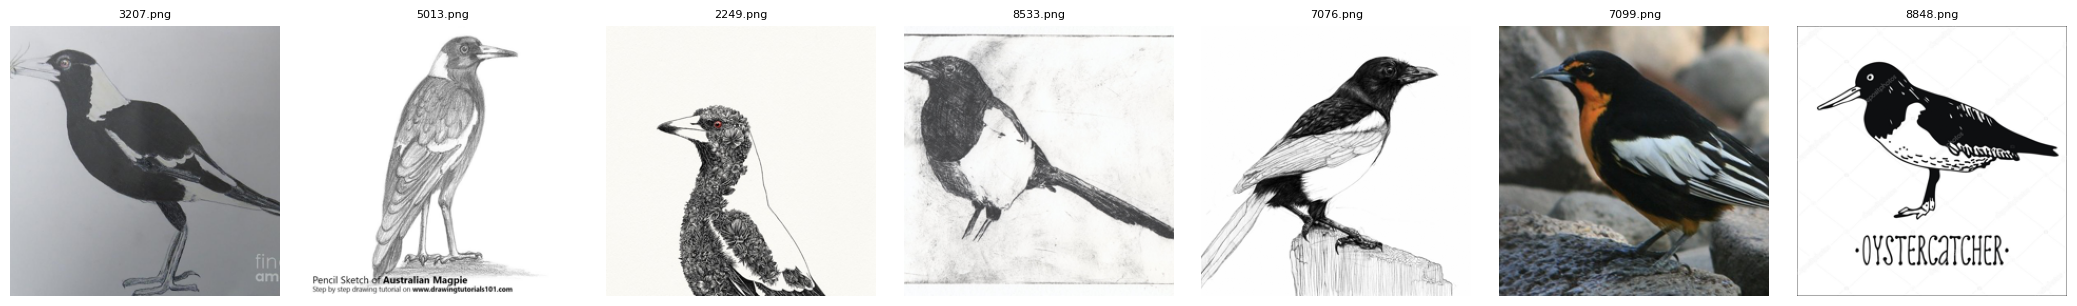

In [109]:

result = [res.iloc[3207].tolist()[0]]
for i in res.iloc[3207].tolist()[1].split():
    result.append(i)
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 7, figsize=(21, 3))  # Ширина 21 дюйм для 7 изображений

# Убираем оси и отображаем изображения
for i, (ax, img_file) in enumerate(zip(axes, result)):
    img = mpimg.imread("./dataset/"+img_file)
    ax.imshow(img)
    ax.set_title(img_file, fontsize=8)  # Подпись с названием (уменьшенный шрифт)
    ax.axis('off')  # Скрываем оси

plt.tight_layout()  # Автоматическая настройка отступов
plt.show()

In [390]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=7, metric="cosine")
knn.fit(embedding_X)

import numpy as np
from tqdm import tqdm

res = pd.DataFrame()
# Теперь делаем запрос
for i in tqdm(range(9605)):
    query_embedding = embedding_X[i].reshape(1,embedding_X.shape[1])
    query_embedding = query_embedding / np.linalg.norm(query_embedding)
    distances, indices = knn.kneighbors(query_embedding, n_neighbors=7)
    indices = pd.DataFrame(indices)
    res = pd.concat((res,indices), axis=0)

rank_columns = [1,2,3,4,5,6]
res['ranking'] = res[rank_columns].apply(
    lambda row: ' '.join([f"{x:04d}.png" for x in row]),
    axis=1
)
res = res.drop(rank_columns, axis=1)
res[0] = res[0].map(lambda x: f"{x:04d}.png")
res = res.rename(columns={0:"filename"})


100%|██████████| 9605/9605 [03:46<00:00, 42.33it/s]


In [392]:
res.to_csv("res.csv", index=False)